In [1]:
!pip install anndata==0.8.0

In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import anndata as ad
from sklearn.manifold import TSNE

In [ ]:
#input: Full adata and SAM object alongside neuronal adata
#output: Anndata object with low quality clusters removed

In [52]:
dat = sc.read_h5ad('../../Testing_Raw_Dat_RNASEQ_Joined/tot_dat_DR_ncbi_joined_07152026.h5ad')

In [2]:
cj_dat = sc.read_h5ad('../../Testing_Raw_Dat_RNASEQ_Joined/tot_dat_DR_neuron_geneexp_07162026.h5ad')

In [3]:
cj_dat

AnnData object with n_obs × n_vars = 51961 × 25503
    obs: 'n_genes', 'n_counts', 'key', 'eq_subclass', 'eq_subclass_lc', 'leiden_clusters', 'eq_subclass_nounlabeled'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions'
    uns: 'dimred_indices', 'path_to_file', 'preprocess_args', 'ranked_genes', 'run_args'
    obsm: 'Raw_X', 'X_pca', 'X_processed', 'X_umap'
    varm: 'PCs'
    layers: 'X_disp'
    obsp: 'connectivities', 'distances', 'nnm'

In [6]:
sam_cj = SAM()
sam_cj.load_data('../../Active_SAM_joined/SAM_DR_neuron_geneexp_07162026.h5ad')
gene_dict_cj = {}
for i in range(len(sam_cj.adata.var_names)):
    gene_dict_cj[sam_cj.adata.var_names[i]] = i

In [7]:
len(set(sam_cj.adata.obs_names) & set(cj_dat.obs_names))/len(set(sam_cj.adata.obs_names))

1.0

In [8]:
len(cj_dat) - len(sam_cj.adata)

0

In [9]:
sam_cj.adata.obs['key']

AAACCTGAGGTGACCA       DarioRerio1
AAACCTGCAGTAGAGC       DarioRerio1
AAACCTGGTAGAGCTG       DarioRerio1
AAACCTGTCATCGATG       DarioRerio1
AAACCTGTCGCCATAA       DarioRerio1
                          ...     
TTTGTCACACACCGCA      DanioRerio16
TTTGTCACATTATCTC      DanioRerio16
TTTGTCAGTCCGAGTC-2    DanioRerio16
TTTGTCAGTGACTACT-1    DanioRerio16
TTTGTCATCACCGGGT      DanioRerio16
Name: key, Length: 51961, dtype: category
Categories (16, object): ['DanioRerio2', 'DanioRerio3', 'DanioRerio4', 'DanioRerio5', ..., 'DanioRerio14', 'DanioRerio15', 'DanioRerio16', 'DarioRerio1']

In [10]:
#Manually set (choose a resolution that clusters the data well)
sam_cj.clustering(param = 1)

In [11]:
sam_cj.adata.obs['leiden_clusters'].nunique()

37

In [12]:
level = 'leiden_clusters'

In [18]:
Xtsne = TSNE(n_components=2, metric = 'cosine').fit_transform(sam_cj.adata.obsm['X_pca'])

/scratch/miniconda/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/scratch/miniconda/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,
/scratch/miniconda/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:827: FutureWarning: 'square_distances' has been introduced in 0.24 to help phase out legacy squaring behavior. The 'legacy' setting will be removed in 1.1 (renaming of 0.26), and the default setting will be changed to True. In 1.3, 'square_distances' will be removed altogether, and distances will be squared by default. Set 'square_distances'=True to silence this warning.
  FutureWarning,


In [68]:
sam_cj.adata.obsm['X_tsne'] = Xtsne

NameError: name 'Xtsne' is not defined

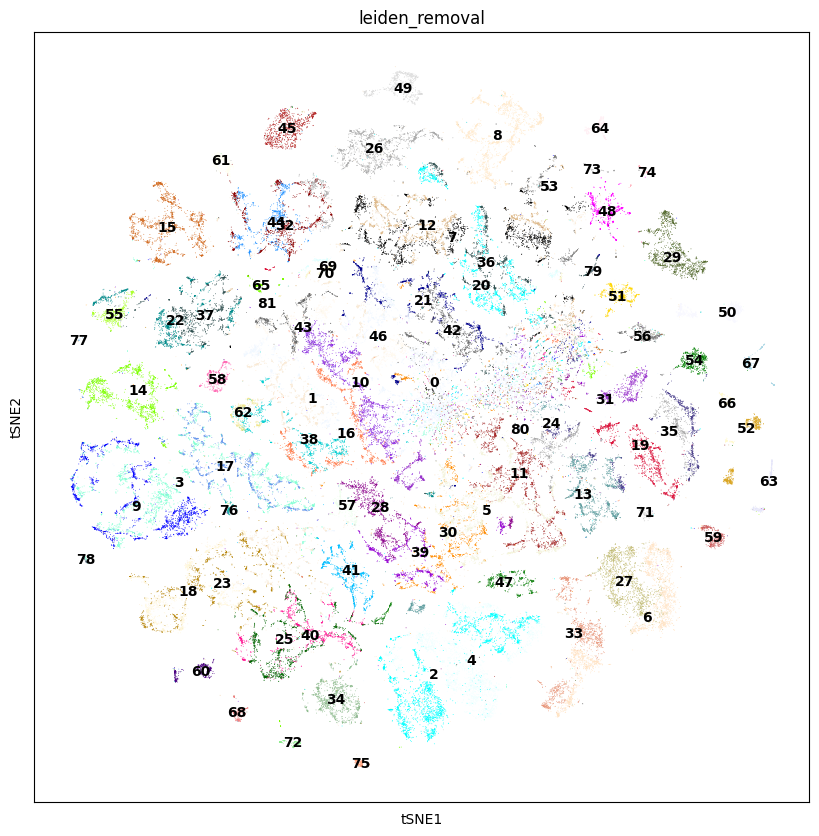

In [20]:
sns.reset_orig()
plt.rcParams['figure.figsize'] = 10,10
sc.pl.tsne(sam_cj.adata, color = 'leiden_removal', palette = list(matplotlib.colors.CSS4_COLORS), legend_loc='on data')

In [13]:
cj_dat.obs[level] = sam_cj.adata.obs[level]

In [ ]:
#look for marker genes
sc.pl.dotplot(cj_dat, ['SLC32A1','SLC17A6','SYT1','MBP'], groupby = 'leiden_clusters')

(0.0, 20000.0)

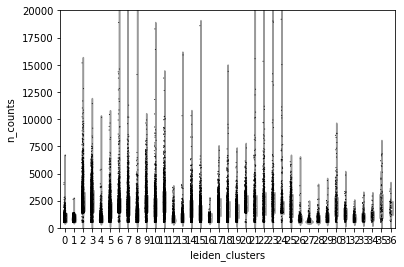

In [14]:
plt.rcParams['figure.figsize'] = 20,10
sns.violinplot(x = 'leiden_clusters', y = 'n_counts', data = cj_dat .obs, color = 'white')
sns.stripplot(x = 'leiden_clusters', y = 'n_counts', data = cj_dat.obs, color = 'black', size = 1)
plt.ylim(0,20000)

(0.0, 7500.0)

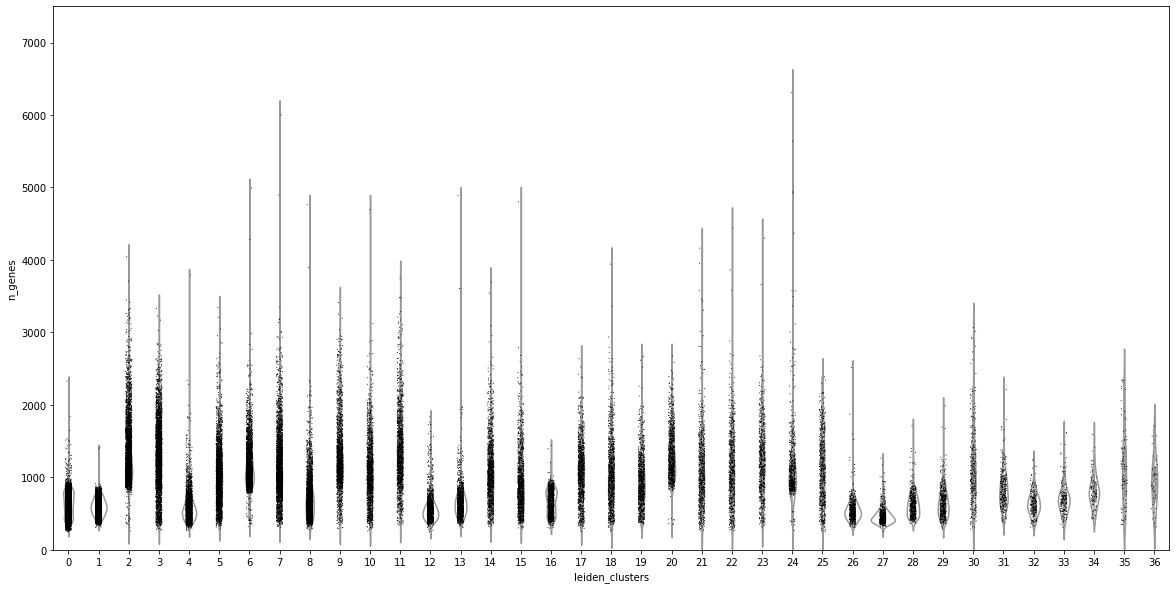

In [15]:
plt.rcParams['figure.figsize'] = 20,10
sns.violinplot(x = 'leiden_clusters', y = 'n_genes', data = cj_dat .obs, color = 'white')
sns.stripplot(x = 'leiden_clusters', y = 'n_genes', data = cj_dat.obs, color = 'black', size = 1)
plt.ylim(0,7500)

In [16]:
ncounts_dict = {}
for item in cj_dat.obs[level].unique():
    val = np.median(cj_dat[cj_dat.obs[level] == item].obs['n_counts'])
    ncounts_dict[item] = val

(array([1., 1., 4., 5., 1., 2., 0., 2., 0., 1., 1., 3., 2., 2., 3., 3., 1.,
        2., 1., 2.]),
 array([ 634. ,  723.5,  813. ,  902.5,  992. , 1081.5, 1171. , 1260.5,
        1350. , 1439.5, 1529. , 1618.5, 1708. , 1797.5, 1887. , 1976.5,
        2066. , 2155.5, 2245. , 2334.5, 2424. ], dtype=float32),
 <BarContainer object of 20 artists>)

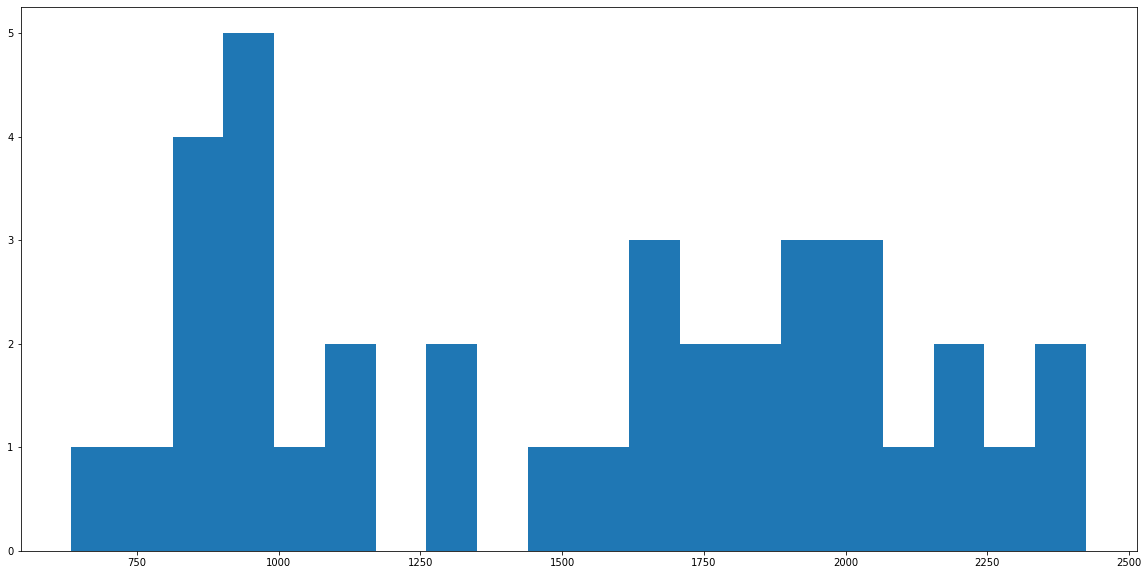

In [17]:
plt.hist(ncounts_dict.values(), bins = 20)

In [35]:
ncounts = list(ncounts_dict.values())
threshold = np.percentile(ncounts, 30)
threshold

1006.1999999999999

In [36]:
#Manually set based on the histogram
rct = set([i for i in ncounts_dict.keys() if ncounts_dict[i]< threshold])

In [37]:
rct

{0, 1, 4, 12, 13, 16, 26, 27, 28, 29, 32}

In [38]:
np.mean(list(ncounts_dict.values()))/2

757.9121704101562

In [39]:
below_half = set([i for i in ncounts_dict.keys() if ncounts_dict[i]< np.mean(list(ncounts_dict.values()))/2])

In [40]:
below_half

{27}

In [41]:
ncounts_dict[33]

1016.5

In [59]:
from tqdm import tqdm

def marker_genes(adata,level,ct,frac = .1,lf = 1, alpha = .05):
    marker_dict = {}
    diff_dict = {}
    gene_dict = {gene: idx for idx, gene in enumerate(adata.var_names)}
    exp = adata.X.A
    for item in tqdm(ct):
        #get differentially expressed genes
        item = str(item)
        sc.tl.rank_genes_groups(adata, groupby=level, method='wilcoxon')
        diff_genes = sc.get.rank_genes_groups_df(adata, group = [item])
        diff_dict[item] = diff_genes

        #set thresholds to speed up the background calculation 
        sig_genes = diff_genes[(diff_genes['pvals_adj'] < alpha) & (diff_genes['logfoldchanges'] > lf)]
        group_mask = adata.obs[level] == item
        background_mask = ~group_mask

        #get background expression (fraction of background cells that express)
        bkgd_exp = []
        for gene in sig_genes['names']:
            detection = (exp[background_mask,gene_dict[gene]] > 0).sum() / background_mask.sum()
            bkgd_exp.append(detection)
        sig_genes['background_exp'] = bkgd_exp

        #set threshold on background expression 
        sig_genes = sig_genes[sig_genes['background_exp'] < frac]
        marker_dict[item] = sig_genes
    return(marker_dict, diff_dict)

In [60]:
marker_dict, diff_dict = marker_genes(sam_cj.adata,'leiden_clusters',[0], frac = .1, lf = .5)

  0%|                                                     | 0/1 [00:00<?, ?it/s]/scratch/miniconda/lib/python3.7/site-packages/scanpy/tools/_rank_genes_groups.py:394: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/scratch/miniconda/lib/python3.7/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
/scratch/miniconda/lib/python3.7/site-packages/scanpy/tools/_ra

In [70]:
marker_dict['0'].head(10)

,names,scores,logfoldchanges,pvals,pvals_adj,background_exp
47,dlx2a,16.340147,1.940617,5.113019e-60,1.762126e-57,0.071477
51,upp1,15.847442,1.737701,1.464217e-56,4.787427e-54,0.085506
80,slc6a1a,14.030208,1.590615,1.018530e-44,2.182821e-42,0.082523
86,ncam2,13.693055,1.823250,1.117116e-42,2.243292e-40,0.066627
91,dre-mir-132-2,13.537526,1.755593,9.389848e-42,1.800521e-39,0.074575
98,slc6a1b,13.375259,1.851466,8.435928e-41,1.536725e-38,0.059545
99,kcnf1b,13.328901,1.461565,1.571966e-40,2.843252e-38,0.095514
107,zgc:162858,12.697157,1.388750,6.131676e-37,1.008878e-34,0.085333
110,tmem9b,12.551237,1.258685,3.913494e-36,6.316826e-34,0.099036
118,prnprs3,12.266680,1.295768,1.367469e-34,2.051444e-32,0.095514


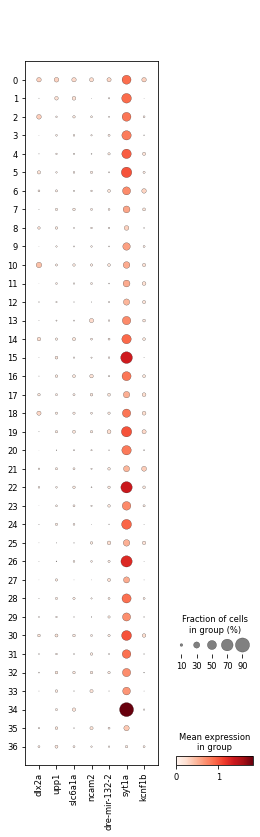

In [73]:
sc.pl.dotplot(cj_dat,groupby = 'leiden_clusters',var_names=['dlx2a','upp1','slc6a1a','ncam2','dre-mir-132-2','syt1a','kcnf1b'])

In [53]:
#Put the cell clusters you want to remove here
cleaned_cells = set(cj_dat[cj_dat.obs['leiden_clusters'].isin([0])].obs_names)

In [54]:
a = 0
for item in cleaned_cells:
    if item in cj_dat.obs_names:
        a += 1

In [55]:
a

5188

In [56]:
cleaned_adata = dat[~dat.obs_names.isin(cleaned_cells)]

In [57]:
cleaned_adata

View of AnnData object with n_obs × n_vars = 61430 × 25503
    obs: 'n_genes', 'n_counts', 'key'

In [75]:
cj_dat.obs['key'].unique()

['DarioRerio1', 'DanioRerio2', 'DanioRerio3', 'DanioRerio4', 'DanioRerio5', ..., 'DanioRerio12', 'DanioRerio13', 'DanioRerio14', 'DanioRerio15', 'DanioRerio16']
Length: 16
Categories (16, object): ['DanioRerio2', 'DanioRerio3', 'DanioRerio4', 'DanioRerio5', ..., 'DanioRerio14', 'DanioRerio15', 'DanioRerio16', 'DarioRerio1']

In [189]:
cleaned_adata.write_h5ad('')